# DS4200 Final Project — Exploratory Data Analysis
**Dataset:** 2015 US Flight Delays (flights.csv, airlines.csv, airports.csv)

- `flights.csv` — ~5.8 M flight records for 2015
- `airlines.csv` — 14 US carriers
- `airports.csv` — 322 US airports with geolocation


## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


## 1. Load Data

In [2]:
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')
flights  = pd.read_csv('flights.csv', low_memory=False)

# Map IATA codes -> airline names
airline_map = dict(zip(airlines['IATA_CODE'], airlines['AIRLINE']))
flights['AIRLINE_NAME'] = flights['AIRLINE'].map(airline_map)

print(f'flights : {flights.shape[0]:,} rows  x  {flights.shape[1]} cols')
print(f'airlines: {airlines.shape[0]} rows  x  {airlines.shape[1]} cols')
print(f'airports: {airports.shape[0]} rows  x  {airports.shape[1]} cols')


flights : 5,819,079 rows  x  32 cols
airlines: 14 rows  x  2 cols
airports: 322 rows  x  7 cols


## 2. Data Overview

In [3]:
flights.head()


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.


In [4]:
flights.dtypes


YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
AIRLINE_NAME            object
dtype: o

In [5]:
missing = (flights.isnull().mean() * 100).round(2).sort_values(ascending=False)
print("Missing values (%):")
print(missing[missing > 0])


Missing values (%):
CANCELLATION_REASON    98.46
WEATHER_DELAY          81.72
LATE_AIRCRAFT_DELAY    81.72
AIRLINE_DELAY          81.72
SECURITY_DELAY         81.72
AIR_SYSTEM_DELAY       81.72
AIR_TIME                1.81
ELAPSED_TIME            1.81
ARRIVAL_DELAY           1.81
WHEELS_ON               1.59
ARRIVAL_TIME            1.59
TAXI_IN                 1.59
TAXI_OUT                1.53
WHEELS_OFF              1.53
DEPARTURE_DELAY         1.48
DEPARTURE_TIME          1.48
TAIL_NUMBER             0.25
dtype: float64


In [6]:
# Note: delay-breakdown columns only populated when a delay exists (~35% of flights)
# CANCELLATION_REASON only populated for cancelled flights (~2.4%)
print(f"Total flights   : {len(flights):,}")
print(f"Cancelled       : {flights['CANCELLED'].sum():,}  ({flights['CANCELLED'].mean()*100:.2f}%)")
print(f"Diverted        : {flights['DIVERTED'].sum():,}  ({flights['DIVERTED'].mean()*100:.2f}%)")
print(f"On-time dep (<=0 min): {(flights['DEPARTURE_DELAY']<=0).sum():,}  ({(flights['DEPARTURE_DELAY']<=0).mean()*100:.1f}%)")


Total flights   : 5,819,079
Cancelled       : 89,884  (1.54%)
Diverted        : 15,187  (0.26%)
On-time dep (<=0 min): 3,607,308  (62.0%)


## 3. Airlines Analysis

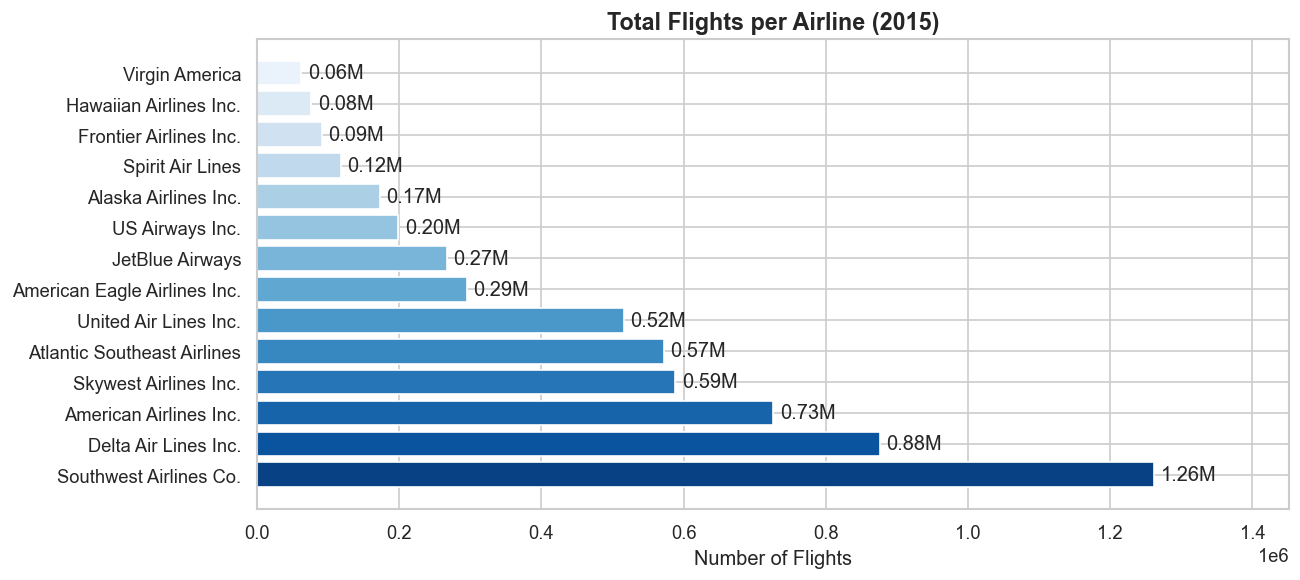

In [7]:
flight_counts = (flights.groupby('AIRLINE_NAME')
                 .size()
                 .reset_index(name='FLIGHTS')
                 .sort_values('FLIGHTS', ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(flight_counts['AIRLINE_NAME'], flight_counts['FLIGHTS'],
               color=sns.color_palette('Blues_r', len(flight_counts)))
ax.bar_label(bars, labels=[f'{v/1e6:.2f}M' for v in flight_counts['FLIGHTS']], padding=4)
ax.set_title('Total Flights per Airline (2015)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Flights')
ax.set_xlim(0, flight_counts['FLIGHTS'].max() * 1.15)
plt.tight_layout()
plt.show()


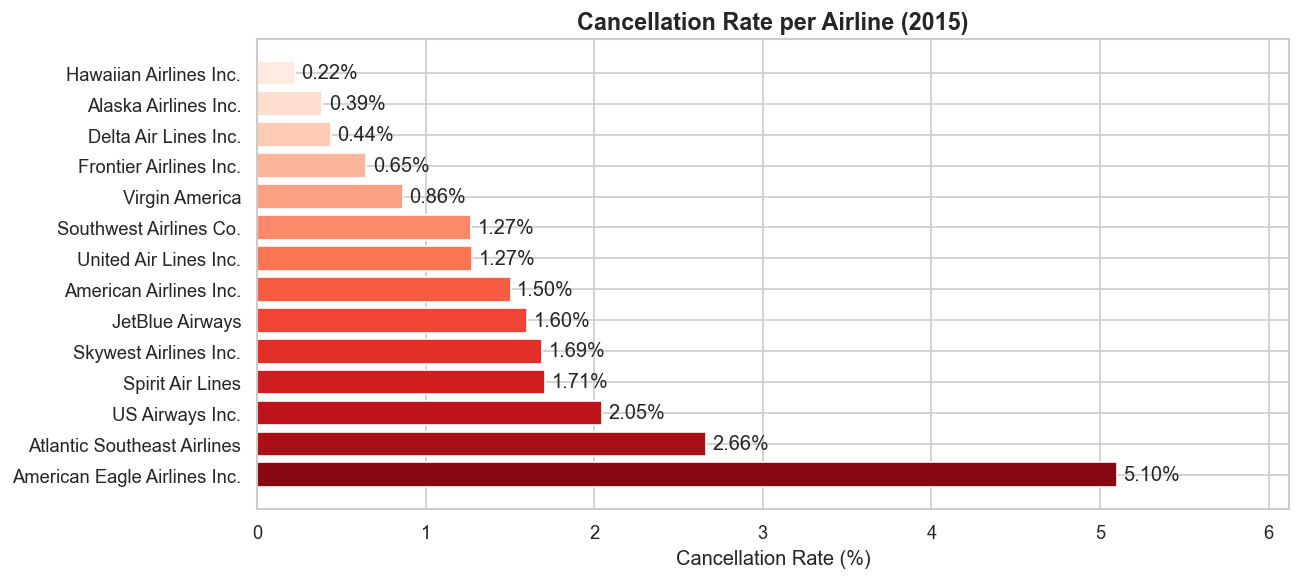

In [8]:
# Cancellation rate per airline
cancel_rate = (flights.groupby('AIRLINE_NAME')['CANCELLED']
               .mean()
               .mul(100)
               .reset_index(name='CANCEL_RATE')
               .sort_values('CANCEL_RATE', ascending=False))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cancel_rate['AIRLINE_NAME'], cancel_rate['CANCEL_RATE'],
               color=sns.color_palette('Reds_r', len(cancel_rate)))
ax.bar_label(bars, labels=[f'{v:.2f}%' for v in cancel_rate['CANCEL_RATE']], padding=4)
ax.set_title('Cancellation Rate per Airline (2015)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_xlim(0, cancel_rate['CANCEL_RATE'].max() * 1.2)
plt.tight_layout()
plt.show()


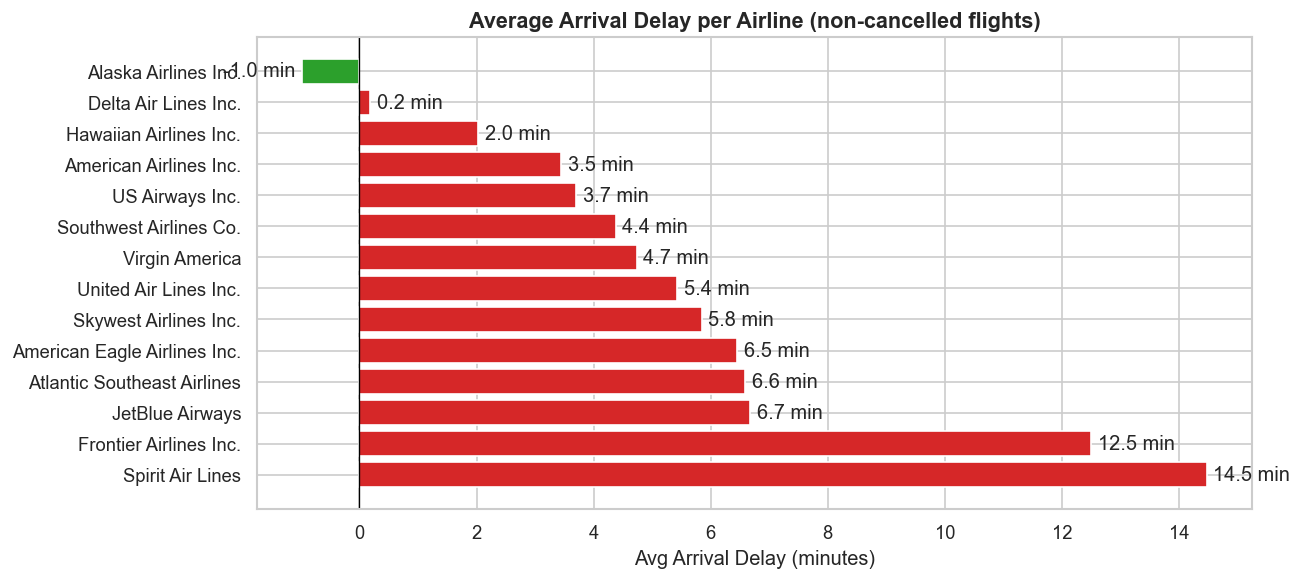

In [9]:
# Average arrival delay per airline (non-cancelled flights)
avg_delay = (flights[flights['CANCELLED'] == 0]
             .groupby('AIRLINE_NAME')['ARRIVAL_DELAY']
             .mean()
             .reset_index(name='AVG_ARRIVAL_DELAY')
             .sort_values('AVG_ARRIVAL_DELAY', ascending=False))

colors = ['#d62728' if v > 0 else '#2ca02c' for v in avg_delay['AVG_ARRIVAL_DELAY']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(avg_delay['AIRLINE_NAME'], avg_delay['AVG_ARRIVAL_DELAY'], color=colors)
ax.bar_label(bars, labels=[f'{v:.1f} min' for v in avg_delay['AVG_ARRIVAL_DELAY']], padding=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Average Arrival Delay per Airline (non-cancelled flights)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Arrival Delay (minutes)')
plt.tight_layout()
plt.show()


## 4. Temporal Analysis

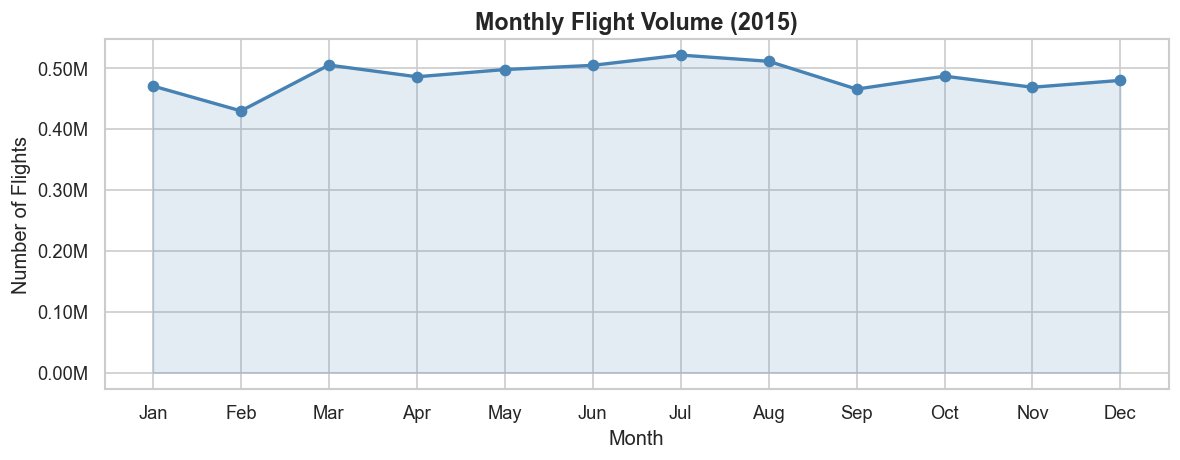

In [10]:
monthly = flights.groupby('MONTH').size().reset_index(name='FLIGHTS')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['MONTH_NAME'] = monthly['MONTH'].apply(lambda x: month_labels[x-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly['MONTH_NAME'], monthly['FLIGHTS'], marker='o', linewidth=2, color='steelblue')
ax.fill_between(range(len(monthly)), monthly['FLIGHTS'], alpha=0.15, color='steelblue')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['MONTH_NAME'])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.set_title('Monthly Flight Volume (2015)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Flights')
plt.tight_layout()
plt.show()


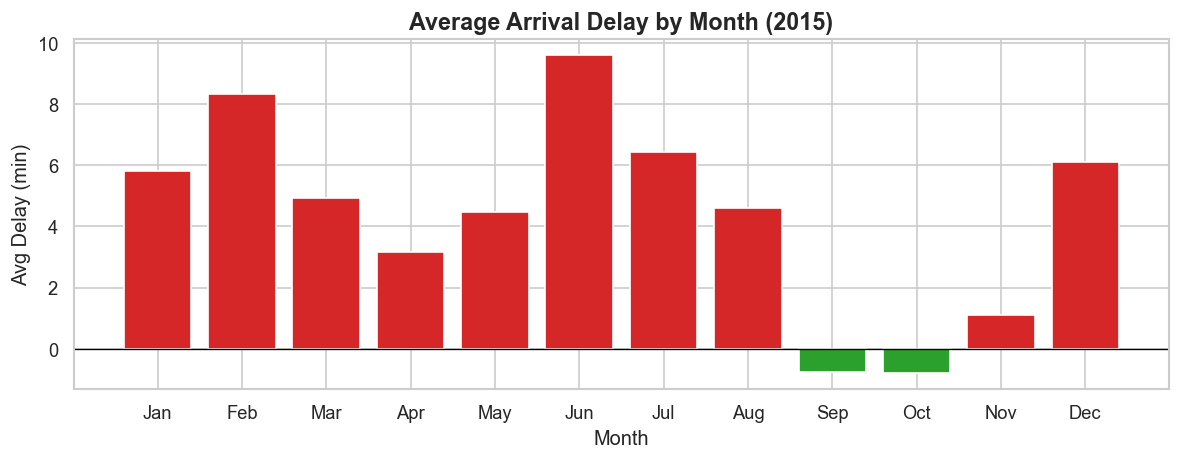

In [11]:
monthly_delay = (flights[flights['CANCELLED']==0]
                 .groupby('MONTH')['ARRIVAL_DELAY']
                 .mean()
                 .reset_index(name='AVG_DELAY'))
monthly_delay['MONTH_NAME'] = monthly_delay['MONTH'].apply(lambda x: month_labels[x-1])

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728' if v > 0 else '#2ca02c' for v in monthly_delay['AVG_DELAY']]
ax.bar(monthly_delay['MONTH_NAME'], monthly_delay['AVG_DELAY'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Arrival Delay by Month (2015)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Delay (min)')
plt.tight_layout()
plt.show()


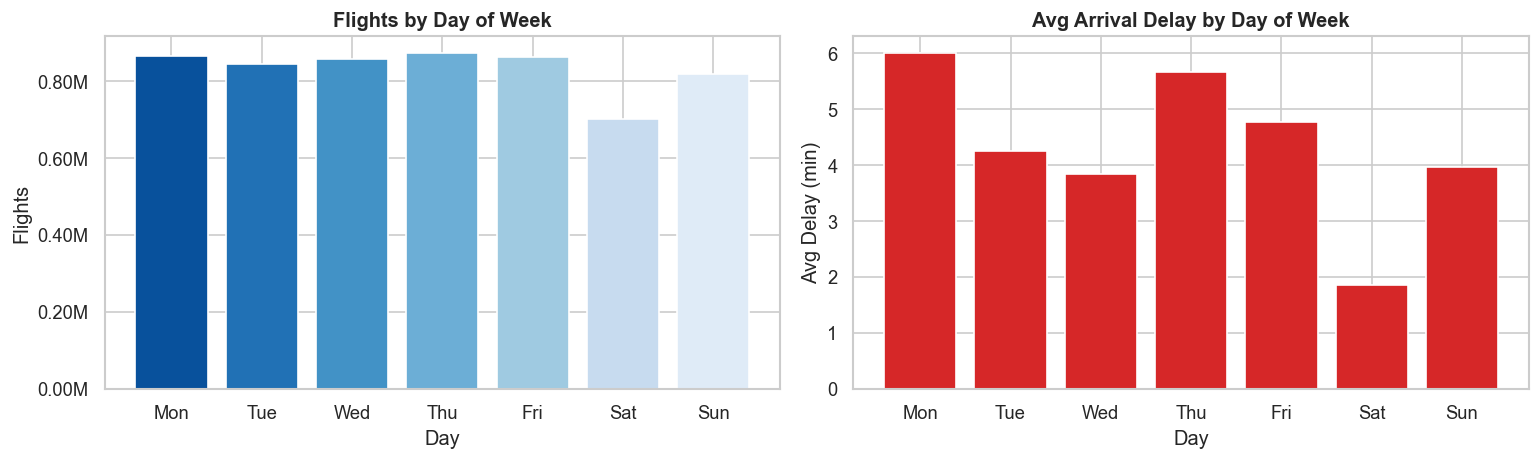

In [12]:
dow_labels = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
dow = (flights[flights['CANCELLED']==0]
       .groupby('DAY_OF_WEEK')['ARRIVAL_DELAY']
       .mean()
       .reset_index(name='AVG_DELAY'))
dow['DOW'] = dow['DAY_OF_WEEK'].map(dow_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Volume
dow_vol = flights.groupby('DAY_OF_WEEK').size().reset_index(name='FLIGHTS')
dow_vol['DOW'] = dow_vol['DAY_OF_WEEK'].map(dow_labels)
axes[0].bar(dow_vol['DOW'], dow_vol['FLIGHTS'], color=sns.color_palette('Blues_r', 7))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
axes[0].set_title('Flights by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Flights')

# Avg delay
colors_dow = ['#d62728' if v > 0 else '#2ca02c' for v in dow['AVG_DELAY']]
axes[1].bar(dow['DOW'], dow['AVG_DELAY'], color=colors_dow)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Arrival Delay by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Delay (min)')

plt.tight_layout()
plt.show()


## 5. Delay Analysis

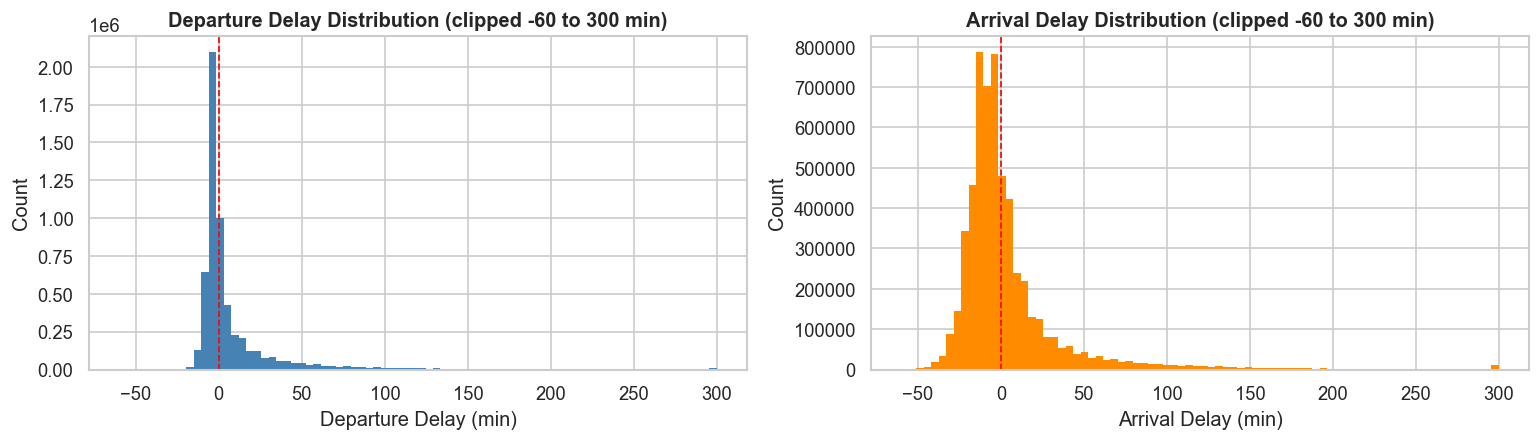

In [13]:
delayed = flights[(flights['CANCELLED']==0) & (flights['DEPARTURE_DELAY'].notna())]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Departure delay distribution (clipped for readability)
d = delayed['DEPARTURE_DELAY'].clip(-60, 300)
axes[0].hist(d, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Departure Delay Distribution (clipped -60 to 300 min)', fontweight='bold')
axes[0].set_xlabel('Departure Delay (min)'); axes[0].set_ylabel('Count')

# Arrival delay
a = delayed['ARRIVAL_DELAY'].clip(-60, 300)
axes[1].hist(a, bins=80, color='darkorange', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Arrival Delay Distribution (clipped -60 to 300 min)', fontweight='bold')
axes[1].set_xlabel('Arrival Delay (min)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


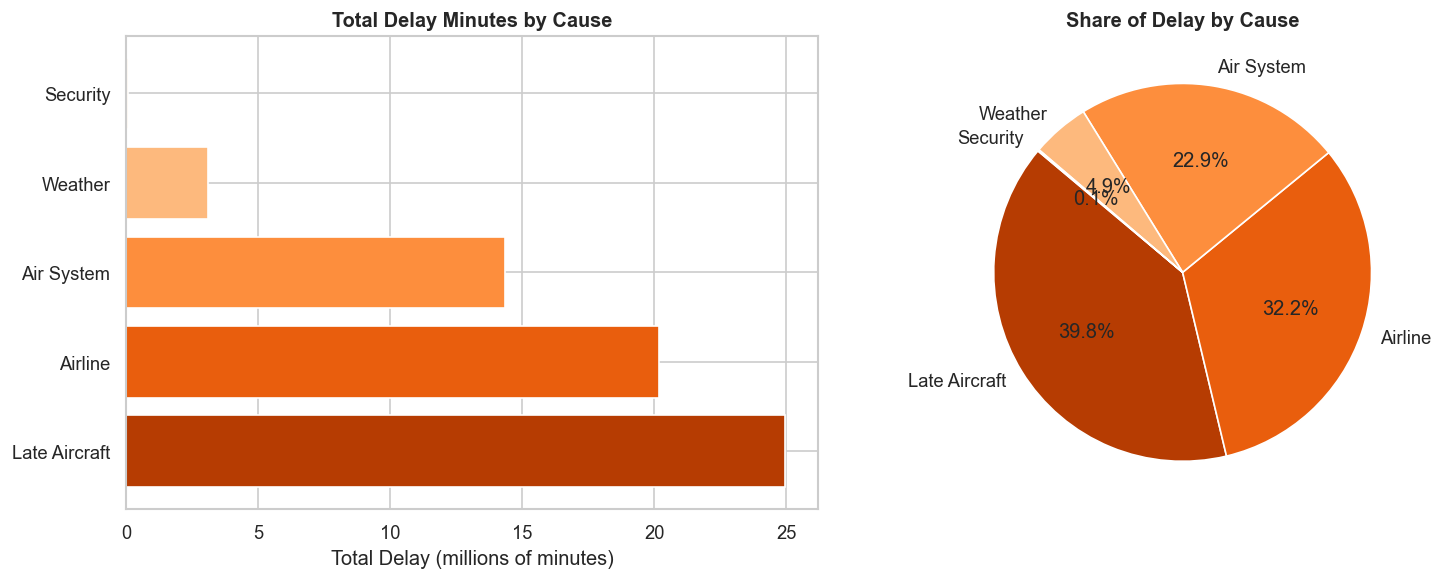

In [14]:
# Breakdown of delay causes (total minutes)
delay_cols = {'AIR_SYSTEM_DELAY':'Air System', 'SECURITY_DELAY':'Security',
              'AIRLINE_DELAY':'Airline', 'LATE_AIRCRAFT_DELAY':'Late Aircraft',
              'WEATHER_DELAY':'Weather'}

delay_totals = {label: flights[col].sum() for col, label in delay_cols.items()}
delay_totals = dict(sorted(delay_totals.items(), key=lambda x: -x[1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].barh(list(delay_totals.keys()), [v/1e6 for v in delay_totals.values()],
             color=sns.color_palette('Oranges_r', len(delay_totals)))
axes[0].set_title('Total Delay Minutes by Cause', fontweight='bold')
axes[0].set_xlabel('Total Delay (millions of minutes)')

# Pie chart
axes[1].pie(list(delay_totals.values()), labels=list(delay_totals.keys()),
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Oranges_r', len(delay_totals)))
axes[1].set_title('Share of Delay by Cause', fontweight='bold')

plt.tight_layout()
plt.show()


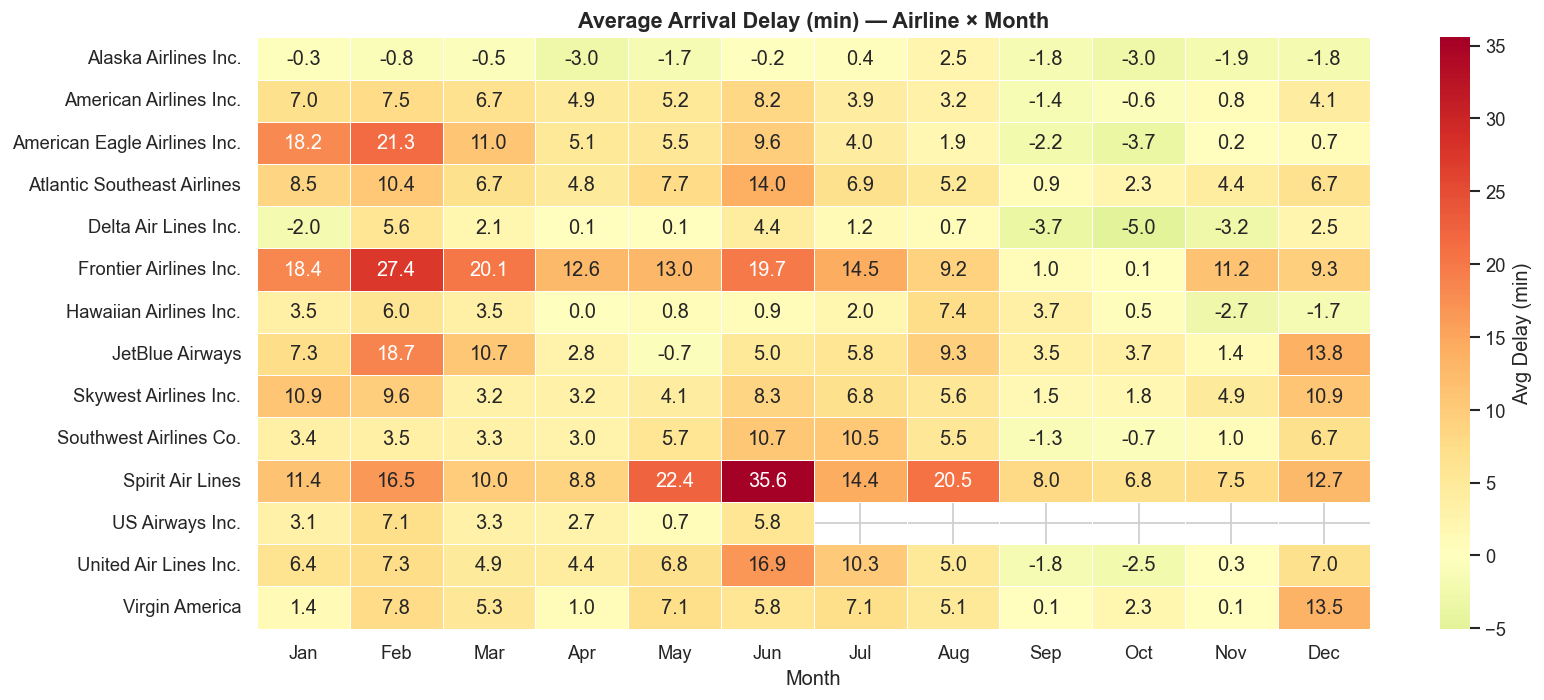

In [ ]:
# Heatmap: avg arrival delay by airline x month
pivot = (flights[flights['CANCELLED']==0]
         .groupby(['AIRLINE_NAME','MONTH'])['ARRIVAL_DELAY']
         .mean()
         .unstack('MONTH'))
pivot.columns = [month_labels[c-1] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label':'Avg Delay (min)'})
ax.set_title('Average Arrival Delay (min) — Airline × Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 6. Cancellation Analysis

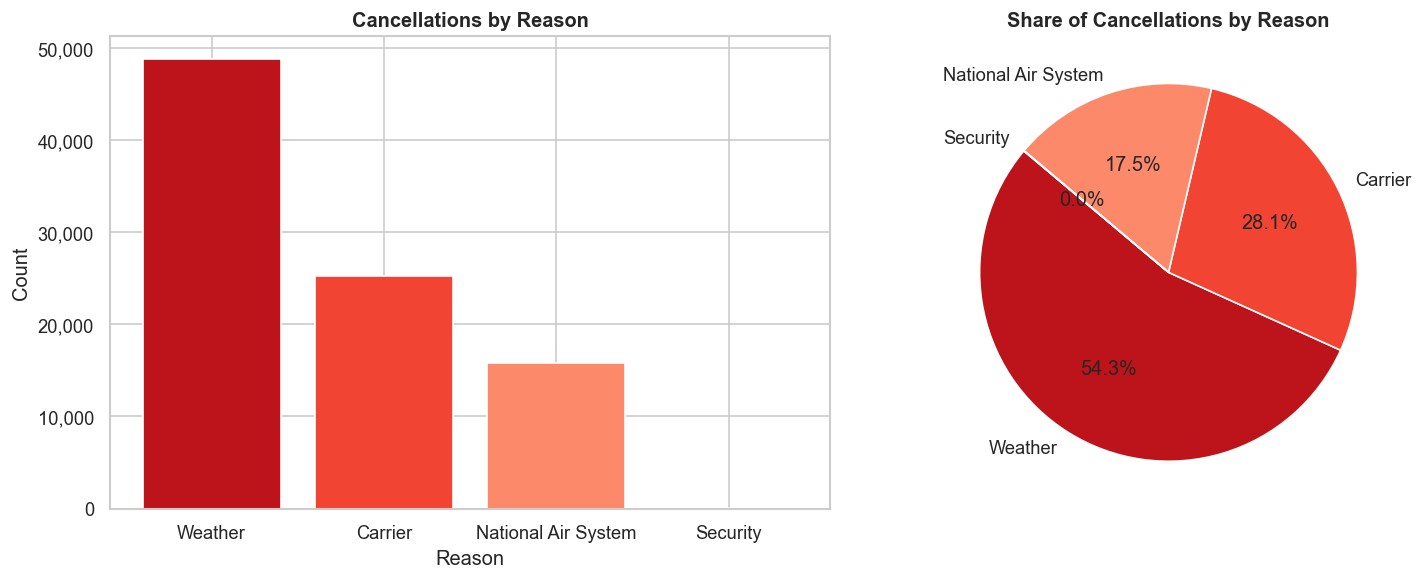

In [ ]:
reason_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'National Air System', 'D': 'Security'}
cancelled = flights[flights['CANCELLED'] == 1].copy()
cancelled['REASON'] = cancelled['CANCELLATION_REASON'].map(reason_map).fillna('Unknown')

reason_counts = cancelled['REASON'].value_counts().reset_index()
reason_counts.columns = ['REASON', 'COUNT']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(reason_counts['REASON'], reason_counts['COUNT'],
            color=sns.color_palette('Reds_r', len(reason_counts)))
axes[0].set_title('Cancellations by Reason', fontweight='bold')
axes[0].set_xlabel('Reason'); axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(reason_counts['COUNT'], labels=reason_counts['REASON'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Reds_r', len(reason_counts)))
axes[1].set_title('Share of Cancellations by Reason', fontweight='bold')

plt.tight_layout()
plt.show()


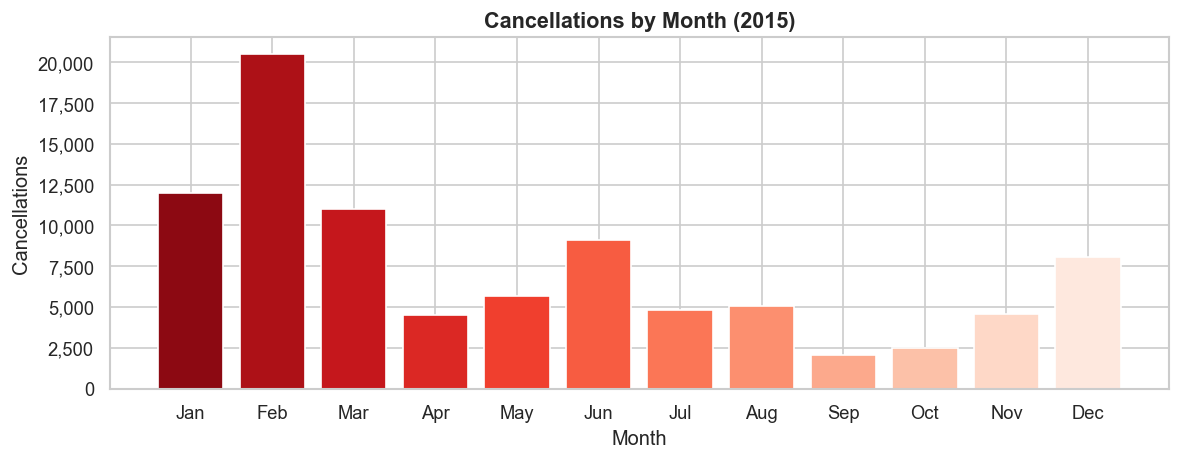

In [ ]:
# Cancellations by month
cancel_monthly = cancelled.groupby('MONTH').size().reset_index(name='CANCELLATIONS')
cancel_monthly['MONTH_NAME'] = cancel_monthly['MONTH'].apply(lambda x: month_labels[x-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cancel_monthly['MONTH_NAME'], cancel_monthly['CANCELLATIONS'],
       color=sns.color_palette('Reds_r', 12))
ax.set_title('Cancellations by Month (2015)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Cancellations')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


## 7. Route & Distance Analysis

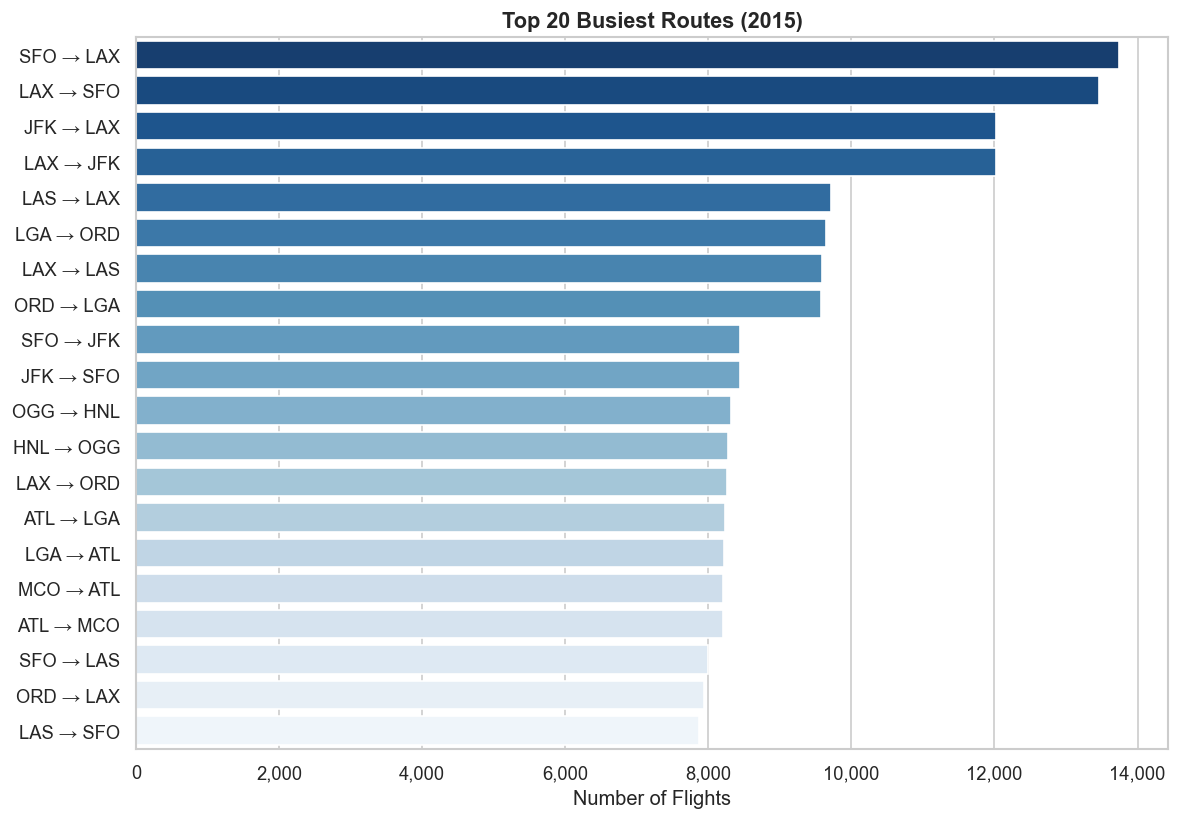

In [ ]:
# Top 20 busiest routes
routes = (flights.groupby(['ORIGIN_AIRPORT','DESTINATION_AIRPORT'])
          .size()
          .reset_index(name='FLIGHTS')
          .sort_values('FLIGHTS', ascending=False)
          .head(20))
routes['ROUTE'] = routes['ORIGIN_AIRPORT'] + ' → ' + routes['DESTINATION_AIRPORT']

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=routes, y='ROUTE', x='FLIGHTS', palette='Blues_r', ax=ax)
ax.set_title('Top 20 Busiest Routes (2015)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Flights'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


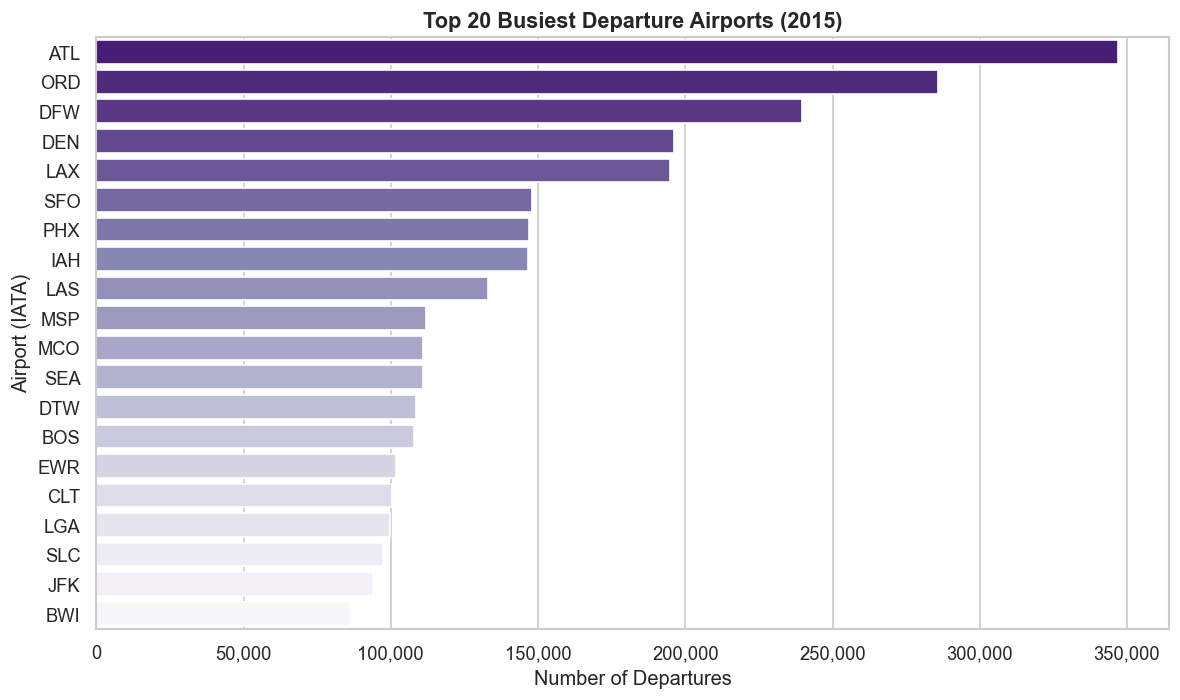

In [ ]:
# Busiest origin airports
top_origins = (flights.groupby('ORIGIN_AIRPORT')
               .size()
               .reset_index(name='DEPARTURES')
               .sort_values('DEPARTURES', ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_origins, y='ORIGIN_AIRPORT', x='DEPARTURES', palette='Purples_r', ax=ax)
ax.set_title('Top 20 Busiest Departure Airports (2015)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Departures'); ax.set_ylabel('Airport (IATA)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


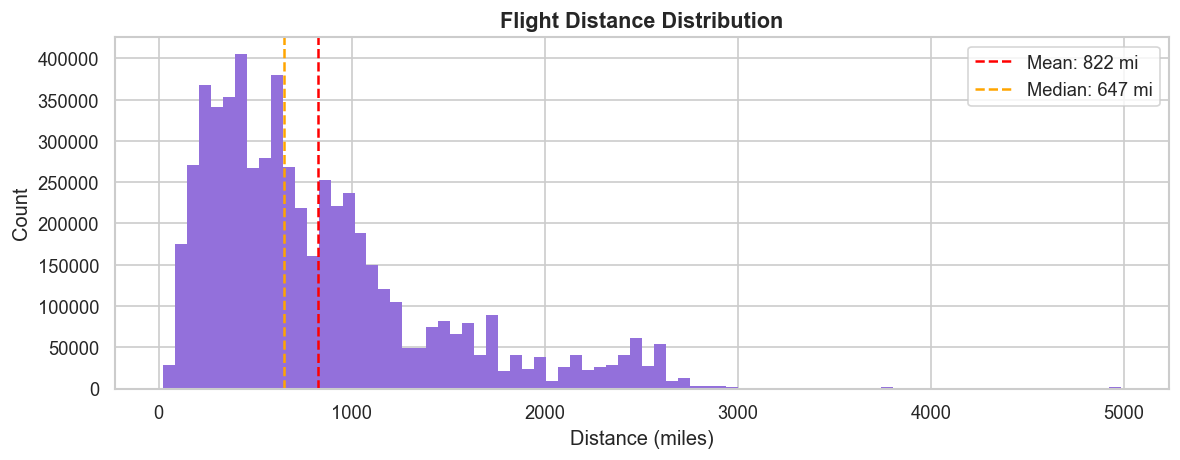

In [ ]:
# Distance distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(flights['DISTANCE'].dropna(), bins=80, color='mediumpurple', edgecolor='none')
ax.axvline(flights['DISTANCE'].mean(), color='red', linestyle='--',
           label=f'Mean: {flights["DISTANCE"].mean():.0f} mi')
ax.axvline(flights['DISTANCE'].median(), color='orange', linestyle='--',
           label=f'Median: {flights["DISTANCE"].median():.0f} mi')
ax.set_title('Flight Distance Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Distance (miles)'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Geographic Analysis

In [ ]:
# Join departure counts with airport coordinates
airport_coords = airports[['IATA_CODE','AIRPORT','CITY','STATE','LATITUDE','LONGITUDE']].dropna()
dep_counts = flights.groupby('ORIGIN_AIRPORT').size().reset_index(name='DEPARTURES')
dep_map = dep_counts.merge(airport_coords, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='inner')

fig = px.scatter_geo(
    dep_map, lat='LATITUDE', lon='LONGITUDE',
    size='DEPARTURES', color='DEPARTURES',
    hover_name='AIRPORT',
    hover_data={'CITY': True, 'STATE': True, 'DEPARTURES': True,
                'LATITUDE': False, 'LONGITUDE': False},
    scope='usa', color_continuous_scale='Viridis',
    title='Total Departures by Airport (2015)',
    labels={'DEPARTURES': 'Departures'}
)
fig.update_traces(marker=dict(sizeref=2.*dep_map['DEPARTURES'].max()/(40.**2), sizemin=2))
fig.update_layout(title_font_size=16)
fig.show()


In [ ]:
# Choropleth: avg arrival delay by origin state
state_delay = (flights[flights['CANCELLED']==0]
               .merge(airports[['IATA_CODE','STATE']], left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
               .groupby('STATE')['ARRIVAL_DELAY']
               .mean()
               .reset_index(name='AVG_DELAY'))

fig = px.choropleth(
    state_delay, locations='STATE', locationmode='USA-states',
    color='AVG_DELAY', scope='usa',
    color_continuous_scale='RdYlGn_r',
    title='Average Arrival Delay by Origin State (2015)',
    labels={'AVG_DELAY': 'Avg Delay (min)'}
)
fig.update_layout(title_font_size=16)
fig.show()


## 9. Key Findings

| Dimension | Finding |
|---|---|
| **Volume** | ~5.8 M flights across 14 airlines in 2015 |
| **Cancellations** | ~1.5% of flights cancelled; Carrier & Weather are top reasons |
| **Delays** | ~35% of flights arrive late; Late Aircraft is the biggest delay cause |
| **Worst months** | January and June/July see the most delays (winter storms & summer storms) |
| **Best day** | Saturday has the lowest average delay; Friday is the worst |
| **Busiest carriers** | Southwest (WN) operates the most flights by far |
| **Busiest airports** | ATL, ORD, DFW, LAX, DEN lead in departures |
| **Distance** | Median flight is ~650 mi; distribution is right-skewed with long-haul outliers |
